In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp

from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
X, y = make_regression(n_samples=100, n_features=3, n_targets=1, noise=50)
df = pd.DataFrame({'feature1': X[:,0], 'feature2': X[:,1], 'feature3': X[:,2], 'target': y})
df.head()

,feature1,feature2,feature3,target
0,-0.924121,0.661818,-0.540349,-82.503448
1,-0.156495,-0.626734,0.457475,90.015436
2,-0.555641,-0.074793,-0.533253,-50.228606
3,1.040910,2.110583,-1.276263,31.376184
4,1.294572,-0.337847,1.164196,181.983894


In [3]:
X = df.iloc[:,0:3]
y = df.iloc[:,-1]

In [4]:
X.shape

(100, 3)

In [5]:
y.shape

(100,)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [7]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[18.13, 6.15,81.22]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['feature1','feature2','feature3']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.007
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,3


In [8]:
y_pred = lr.predict(X_test)

In [9]:
print('MAE: ',mean_absolute_error(y_test, y_pred))
print('MSE: ',mean_squared_error(y_test, y_pred))
print('R2-Score: ',r2_score(y_test, y_pred))

MAE:  39.29429310224857
MSE:  2926.501875730627
R2-Score:  0.7286984036646356


## 1: Linear Relationship:

Text(0.5, 0, 'feature3')

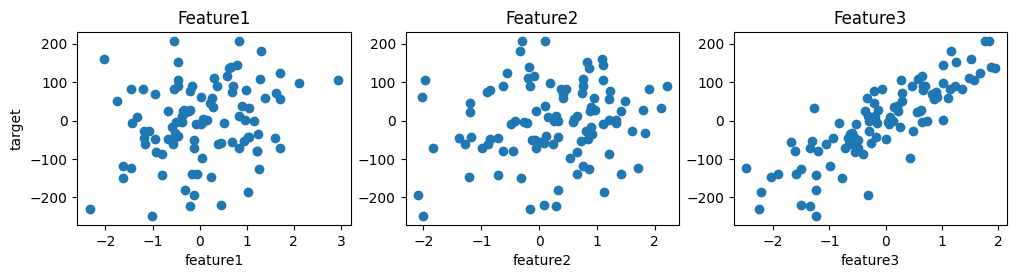

In [10]:
fig, (ax1, ax2, ax3) = plt.subplots(ncols=3, figsize=(12,2.5))

ax1.scatter(df['feature1'], df['target'])
ax1.set_title('Feature1')
ax1.set_xlabel('feature1')
ax1.set_ylabel('target')

ax2.scatter(df['feature2'], df['target'])
ax2.set_title('Feature2')
ax2.set_xlabel('feature2')

ax3.scatter(df['feature3'], df['target'])
ax3.set_title('Feature3')
ax3.set_xlabel('feature3')

## 2: Multicollinearity:
#### 1st Technique:

In [11]:
X_train_vif = sm.add_constant(X_train)

vlf = []
for i in range(1, X_train_vif.shape[1]):  # skip index 0, the constant column
    vlf.append(variance_inflation_factor(X_train_vif.values, i))

In [12]:
pd.DataFrame({'vlf': vlf}, index=df.columns[0:3]).T

,feature1,feature2,feature3
vlf,1.016724,1.013075,1.020653


#### 2nd Technique:

<Axes: >

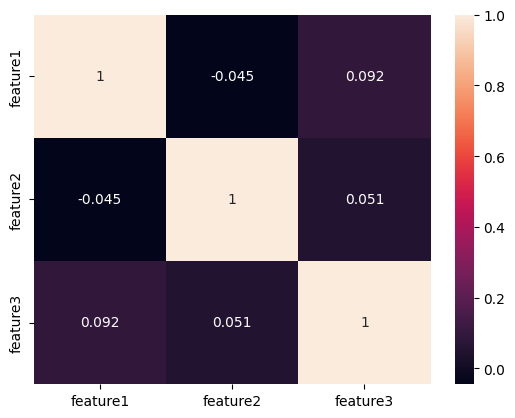

In [13]:
sns.heatmap(df.iloc[:,0:3].corr(), annot=True)

## 3: Normality of Residuals:

In [14]:
residual = y_test - y_pred

<Axes: xlabel='target', ylabel='Density'>

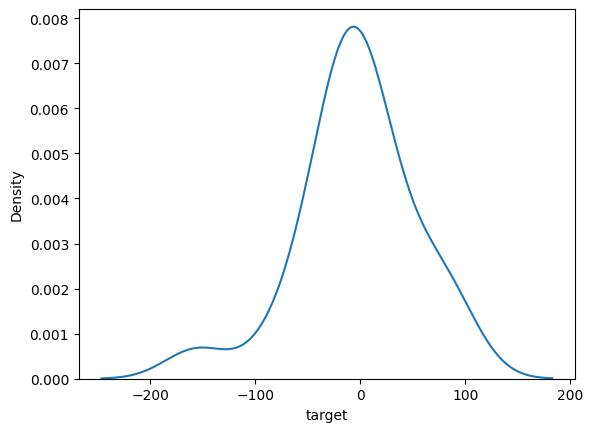

In [15]:
sns.kdeplot(residual)

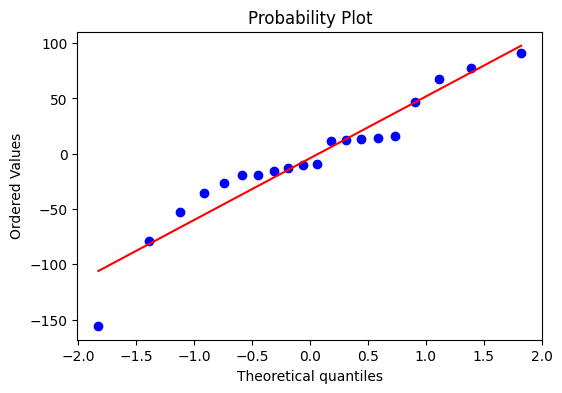

In [16]:
fig, ax = plt.subplots(figsize=(6,4))
sp.stats.probplot(residual, plot=ax, fit=True)

plt.show()

## 4: Homoscedasticity:

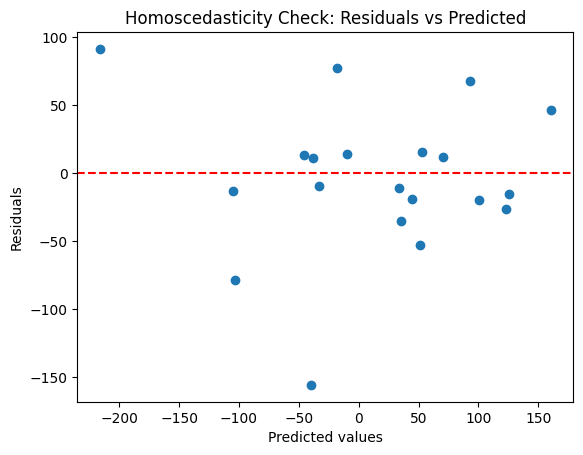

In [17]:
plt.scatter(y_pred, residual)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check: Residuals vs Predicted')
plt.show()

## 5: No Autocorrelation of Errors:

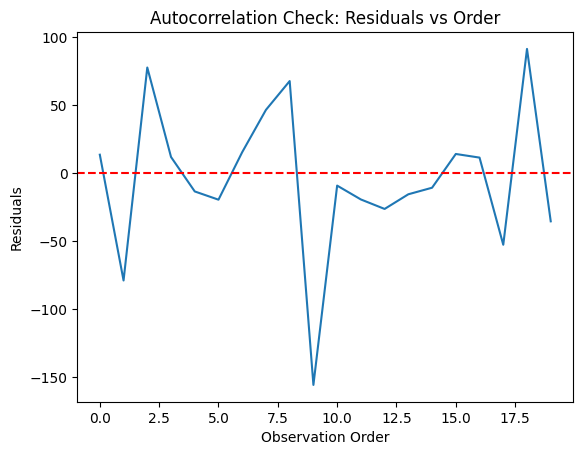

In [18]:
plt.plot(residual.values)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Observation Order')
plt.ylabel('Residuals')
plt.title('Autocorrelation Check: Residuals vs Order')
plt.show()